In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import myutil
import sklearn
sklearn.set_config(transform_output="pandas")

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [103]:
df = pd.read_csv('./data/data.csv')
test = pd.read_csv('./data/test.csv')
sample = pd.read_csv('./data/sample_submission.csv')

In [104]:
print('train shape :', df.shape)
print('test shape  :', test.shape)
print('sample shape:', sample.shape)

train shape : (10578, 16)
test shape  : (3527, 15)
sample shape: (3527, 2)


In [105]:
df.head(3)

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,1000.0
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,700.0
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,260.0


In [106]:
print('train columns:', df.columns.to_list())
print('test columns :', test.columns.to_list())

train columns: ['Property_id', 'Offer', 'URL', 'Property_type', 'Include_w_e', 'Title', 'Area', 'Governorate', 'Beds', 'Baths', 'Size', 'Availability_date', 'Agent_name', 'Agency', 'Amenities', 'rent']
test columns : ['Property_id', 'Offer', 'URL', 'Property_type', 'Include_w_e', 'Title', 'Area', 'Governorate', 'Beds', 'Baths', 'Size', 'Availability_date', 'Agent_name', 'Agency', 'Amenities']


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10578 entries, 0 to 10577
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10578 non-null  int64  
 1   Offer              10578 non-null  str    
 2   URL                10578 non-null  str    
 3   Property_type      10578 non-null  str    
 4   Include_w_e        10578 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10578 non-null  str    
 9   Baths              10578 non-null  str    
 10  Size               10578 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10272 non-null  float64
 15  rent               10575 non-null  float64
dtypes: float64(2), int64(1), str(13)


In [108]:
# count the missing values in each column, for train and for test files
print(f'Train: {df.isnull().sum()}')
print()
print()
print(f'Test: {test.isnull().sum()}')

Train: Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  3
Area                   3
Governorate            3
Beds                   0
Baths                  0
Size                   0
Availability_date    519
Agent_name             3
Agency                 3
Amenities            306
rent                   3
dtype: int64


Test: Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  0
Area                   0
Governorate            0
Beds                   0
Baths                  0
Size                   0
Availability_date    168
Agent_name             0
Agency                 0
Amenities             86
dtype: int64


In [109]:
# check for fully duplicated rows
print('duplicated rows:', df.duplicated().sum())

# Property_id is supposed to be unique, let's check
print('duplicated Property_id:', df['Property_id'].duplicated().sum())

# check duplicates while ignoring the id (the same listing saved more than once under two ids)
print('duplicated listings (ignoring Property_id):', df.drop(columns='Property_id').duplicated().sum())

duplicated rows: 0
duplicated Property_id: 0
duplicated listings (ignoring Property_id): 241


In [110]:
df.describe()

,Property_id,Amenities,rent
count,10578.000000,10272.000000,10575.000000
mean,7059.734260,10.319996,718.750071
std,4080.910374,5.093414,5318.027519
min,2.000000,1.000000,50.000000
25%,3521.250000,6.000000,330.000000
50%,7023.500000,11.000000,450.000000
75%,10605.750000,14.000000,700.000000
max,14103.000000,25.000000,400000.000000


In [111]:
# summary for the TEXT columns
df.describe(exclude=np.number)

,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency
count,10578,10578,10578,10578,10575,10575,10575,10578,10578,10578,10059,10575,10575
unique,1,10337,11,2,9824,127,5,19,9,395,608,461,205
top,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,"Apartment for rent , in a great location:",Al Juffair,Capital Governorate,2,2,"1,292 sqft / 120 sqm",9 Sep 2025,Farhan Tariq,Instant Homz
freq,10578,5,8378,6477,18,1914,5308,3874,4260,923,190,241,469


In [112]:
# look at the values inside the main categorical columns one by one

print(df['Offer'].value_counts(dropna=False))
print()
print()
print(df['Property_type'].value_counts(dropna=False))
print()
print()
print(df['Include_w_e'].value_counts(dropna=False))
print()
print()
print(df['Governorate'].value_counts(dropna=False))

Offer
Rent    10578
Name: count, dtype: int64


Property_type
Apartment                       8378
Villa                           1855
Compound                         133
Duplex                            95
Penthouse                         69
Townhouse                         21
Whole Building                    18
Hotel Apartment                    6
Bulk Rent Unit                     1
Short Term & Hotel Apartment       1
Bungalow                           1
Name: count, dtype: int64


Include_w_e
Inclusive    6477
Exclusive    4101
Name: count, dtype: int64


Governorate
Capital Governorate     5308
Muharraq Governorate    2844
Northern Governorate    1857
Central Governorate      316
Southern Governorate     250
NaN                        3
Name: count, dtype: int64


In [113]:
# Beds, Baths and Size were read as str and not int - let's see why
print(df['Beds'].value_counts())
print()
print()
print(df['Baths'].value_counts())
print()
print()
print(df['Size'].value_counts())
print()
print()

Beds
2               3874
1               2201
3               1332
4+ Maid          832
3+ Maid          748
studio           595
2+ Maid          283
5+ Maid          253
4                236
5                 63
1+ Maid           49
6+ Maid           41
6                 20
7+                18
studio+ Maid       9
7++ Maid           7
7                  7
7+ Maid            7
0                  3
Name: count, dtype: int64


Baths
2       4260
3       2427
1       1583
4       1219
5        739
6        222
7         83
7+        44
none       1
Name: count, dtype: int64


Size
1,292 sqft / 120 sqm       923
1,399 sqft / 130 sqm       570
1,076 sqft / 100 sqm       436
1,184 sqft / 110 sqm       403
1,507 sqft / 140 sqm       364
                          ... 
4,510 sqft / 419 sqm         1
4,176 sqft / 388 sqm         1
2,626 sqft / 244 sqm         1
26,910 sqft / 2,500 sqm      1
6,383 sqft / 593 sqm         1
Name: count, Length: 395, dtype: int64




In [114]:
# check how many different values exist in the text columns
df[['Property_type', 'Governorate', 'Area', 'Agency', 'Agent_name']].nunique()

Property_type     11
Governorate        5
Area             127
Agency           205
Agent_name       461
dtype: int64

In [115]:
# target column
df['rent'].describe()

count     10575.000000
mean        718.750071
std        5318.027519
min          50.000000
25%         330.000000
50%         450.000000
75%         700.000000
max      400000.000000
Name: rent, dtype: float64

In [116]:
print('median rent :', df['rent'].median())
print('mean rent   :', df['rent'].mean())
print('skewness    :', df['rent'].skew())

median rent : 450.0
mean rent   : 718.7500709219859
skewness    : 53.889106111650975


In [117]:
# mean is much bigger than the median, it means a huge values are pulling it 

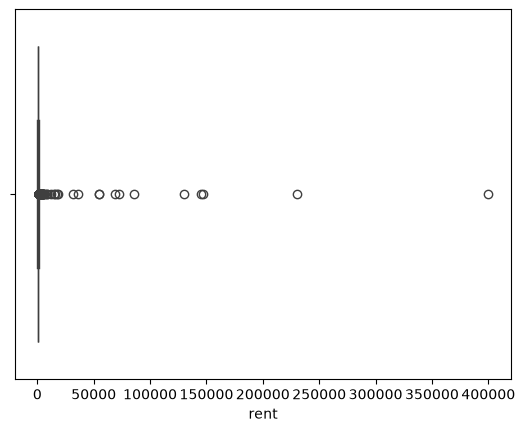

In [118]:
sns.boxplot(x=df['rent'])
plt.show()

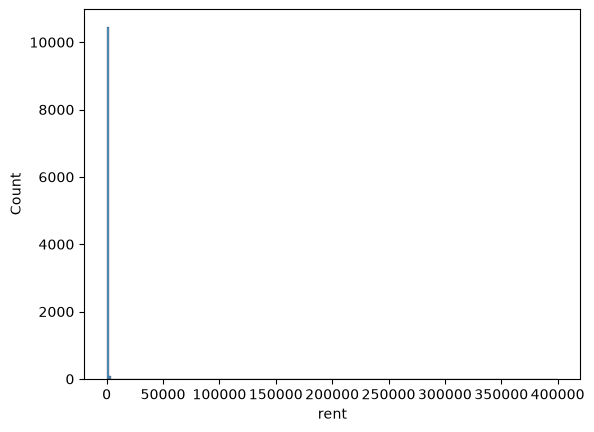

In [119]:
sns.histplot(df['rent'])
plt.show()

In [120]:
df[df['rent'] > 5000]
# these are outliers

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
292,657,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Exclusive Offer | Resort-Style Living | Spacious,"Breeze of Dilmunia, Dilmunia Island",Muharraq Governorate,1,2,"1,012 sqft / 94 sqm",25 Sep 2025,Anjum Jawaid,River West Properties,14.0,72000.0
364,11375,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,Labour Accommodation/Riffa/Whole Bldg./171 Rooms,"Alhajiyat, Riffa",Southern Governorate,7+,7+,"147,918 sqft / 13,742 sqm",26 May 2025,City Property,City Property,4.0,12000.0
1200,9408,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Five-Star Residence with Iconic Skyline Views,Bahrain Bay,Capital Governorate,3+ Maid,4,"2,874 sqft / 267 sqm",24 Jun 2025,Mahmoud Marzouk,HighBridge,18.0,5250.0
1242,3672,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,"Entire New Building – Ideal for Staff, Great Spot","Gudaibiya, Manama",Capital Governorate,studio,1,"21,528 sqft / 2,000 sqm",8 Sep 2025,Eva Gavin,Eva Realty,4.0,8400.0
1467,1544,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,Prestigious Residential Building in Adliya,"Adliya, Manama",Capital Governorate,7++ Maid,7+,"27,523 sqft / 2,557 sqm",20 Sep 2025,Fatima Rahaoui,Kooheji Real Estate & Constructions,11.0,18000.0
2131,11819,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,New Villa in karzakan Size 331 SQM,Karzakkan,Northern Governorate,4+ Maid,5,"4,844 sqft / 450 sqm",24 Feb 2025,Hussain Al Mesbah,Effects Services,1.0,146500.0
2960,13070,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,Prime location | Corner Street | One cheque,Al Juffair,Capital Governorate,7+,7+,"9,569 sqft / 889 sqm",10 Mar 2025,Saud Nasser,Domestic Designs,6.0,14500.0
3311,7717,Rent,https://www.propertyfinder.bh/en/plp/rent/pent...,Penthouse,Inclusive,LUXURY LIVING WITH CRYSTAL BLUE HORIZON,Bahrain Bay,Capital Governorate,4+ Maid,6,"4,413 sqft / 410 sqm",1 Aug 2025,Farhan Tariq,BHH Real Estate,17.0,6500.0
3810,10706,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,Modern | For Rent &amp; Sale | Sea View + Balcony,"Durrat Marina, Durrat Al Bahrain",Southern Governorate,2,3,"1,292 sqft / 120 sqm",29 Apr 2025,Yusuf Alsobaiei,Aqaratcom For Real Estate,14.0,55000.0
4134,7105,Rent,https://www.propertyfinder.bh/en/plp/rent/pent...,Penthouse,Inclusive,PENTHOUSE | LUXURIOUS | MAID ROOM | SEA VIEW,Bahrain Bay,Capital Governorate,4+ Maid,6,"4,413 sqft / 410 sqm",6 Aug 2025,Gulnaz Amangeldinova,Glory Real Estate,15.0,5500.0


In [121]:
df.sort_values('rent', ascending=False).head(15)

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
7195,10705,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Spacious Villa | Patel 5 | 4 Bedrooms,Durrat Al Bahrain,Southern Governorate,4+ Maid,6,"5,866 sqft / 545 sqm",29 Apr 2025,Yusuf Alsobaiei,Aqaratcom For Real Estate,17.0,400000.0
9399,13289,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,UNDER CONSTRUCTION VILLA IN MUHARRAQ,Muharraq,Muharraq Governorate,6,7,"4,036 sqft / 375 sqm",NaN,Hussain Nayem,DELTA REAL ESTATE,NaN,230000.0
2131,11819,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,New Villa in karzakan Size 331 SQM,Karzakkan,Northern Governorate,4+ Maid,5,"4,844 sqft / 450 sqm",24 Feb 2025,Hussain Al Mesbah,Effects Services,1.0,146500.0
7248,6116,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Amazing House for Sale in Hidd,Hidd,Muharraq Governorate,5,7+,"5,813 sqft / 540 sqm",19 Aug 2025,Najeeb Hejres,Green Line Real Estate,4.0,145000.0
4397,11498,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Villa for sale in Sadad,Sadad,Northern Governorate,4,5,"2,939 sqft / 273 sqm",NaN,Ali AlMahafdha,Grnata,NaN,130000.0
9018,11623,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,| CITY CENTER | MODERN | CITY VIEW | HIGH FLOOR |,Seef,Capital Governorate,2+ Maid,2,"1,432 sqft / 133 sqm",6 Mar 2025,Gulnaz Amangeldinova,Glory Real Estate,17.0,86000.0
292,657,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Exclusive Offer | Resort-Style Living | Spacious,"Breeze of Dilmunia, Dilmunia Island",Muharraq Governorate,1,2,"1,012 sqft / 94 sqm",25 Sep 2025,Anjum Jawaid,River West Properties,14.0,72000.0
7277,12923,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,High Floor | Mall View | Beach Access,"Marassi Shores Residences, Diyar Al Muharraq",Muharraq Governorate,1,1,710 sqft / 66 sqm,NaN,Hussain Nayem,DELTA REAL ESTATE,8.0,69000.0
3810,10706,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,Modern | For Rent &amp; Sale | Sea View + Balcony,"Durrat Marina, Durrat Al Bahrain",Southern Governorate,2,3,"1,292 sqft / 120 sqm",29 Apr 2025,Yusuf Alsobaiei,Aqaratcom For Real Estate,14.0,55000.0
4602,11601,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,BRAND NEW BUILDING | PRIME LOCATION | 3BHK,Hamad Town,Northern Governorate,3,4,"1,561 sqft / 145 sqm",28 May 2025,Green Line,Green Line Real Estate,5.0,55000.0


In [122]:
print(f'rent > 10000: {(df['rent'] > 10000).sum()}')
print(f'rent > 5000 : {(df['rent'] > 5000).sum()}')
print(f'rent > 2000 : {(df['rent'] > 2000).sum()}')
print(f'rent < 100  : {(df['rent'] < 100).sum()}')

rent > 10000: 17
rent > 5000 : 22
rent > 2000 : 111
rent < 100  : 3


In [123]:
df.sort_values('rent').head(10)
# to see the lowest

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
8581,3156,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,For rent studio for special price in Manama,Manama,Capital Governorate,1,1,323 sqft / 30 sqm,11 Sep 2025,Yes Real Estate,Yes Real Estate,1.0,50.0
5427,3177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,For Rent small studio for special price in Manama,Manama,Capital Governorate,1,1,323 sqft / 30 sqm,11 Sep 2025,Ali Alkhunaizi,Yes Real Estate,1.0,50.0
4381,11858,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Elegant Semi Furnished 1 Bedroom Apartment,Salmabad,Central Governorate,1,1,269 sqft / 25 sqm,1 Sep 2024,Al-Ahlia Real Estate,Al-Ahlia Real Estate,NaN,90.0
2974,9526,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BHK in very low BUDGET in MUHARRAQ,Muharraq,Muharraq Governorate,2,2,915 sqft / 85 sqm,19 Jun 2025,Dhurgham Ali,AYS Real Estate,1.0,100.0
526,569,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio for rent including electricity,Hidd,Muharraq Governorate,studio,1,538 sqft / 50 sqm,25 Sep 2025,khaled alghaiathi,Paradise House Real Estate,2.0,100.0
10234,12916,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,For rent nice 1bhk in sitra,Sitra,Central Governorate,1,1,646 sqft / 60 sqm,23 Oct 2024,Yes Real Estate,Yes Real Estate,NaN,100.0
1214,10849,Rent,https://www.propertyfinder.bh/en/plp/rent/bulk...,Bulk Rent Unit,Inclusive,Bulk Rooms for rent in Muharraq,Muharraq,Muharraq Governorate,0,7+,"2,153 sqft / 200 sqm",22 Apr 2025,Azhar Uddin,Capital Estate,1.0,100.0
3065,11264,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio for rent in Manama in front of Bab Al B...,"Manama Sea Front, Manama",Capital Governorate,studio,1,807 sqft / 75 sqm,25 Mar 2025,Hussain Hammadi,Hammadi Real Estate Construction And Document ...,1.0,100.0
3209,12393,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BHK Flat in Busaiteen| Affordable Price,Busaiteen,Muharraq Governorate,2,1,915 sqft / 85 sqm,5 Jan 2025,Dhurgham Ali,AYS Real Estate,1.0,100.0
1915,9528,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BHK for FAMILIES in affordable BUDGET | BUSAI...,Busaiteen,Muharraq Governorate,2,2,"1,076 sqft / 100 sqm",19 Jun 2025,Dhurgham Ali,AYS Real Estate,1.0,100.0


In [124]:
# temporary dataframe without the impossible rents
df_temp = df[df['rent'] <= 5000]

print(f"rows before: {df.shape[0]}")
print(f"rows after : {df_temp.shape[0]}")

rows before: 10578
rows after : 10553


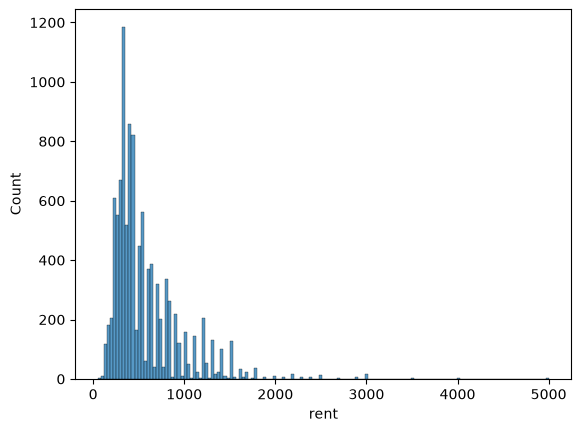

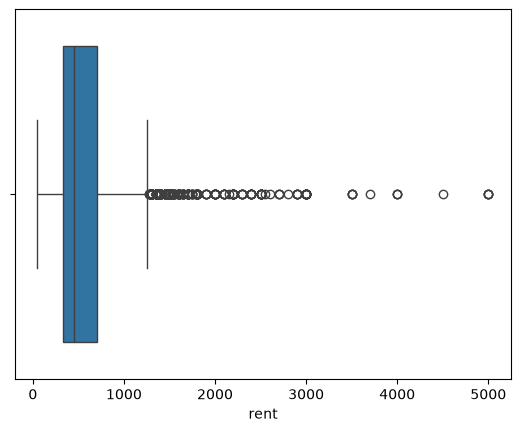

In [125]:
sns.histplot(df_temp['rent'])
plt.show()

sns.boxplot(x=df_temp['rent'])
plt.show()

In [126]:
# check correlation with the target
df.corr(numeric_only=True)[['rent']]

,rent
Property_id,0.019748
Amenities,0.023892
rent,1.000000


In [127]:
# temp conversion, only to look at correlation
temp = df.copy()

temp['size_sqm'] = temp['Size'].str.split('/').str[1].str.replace('sqm', '').str.replace(',', '').astype(float)
temp['beds_n'] = temp['Beds'].str.replace('studio', '0').str[0].astype(float)
temp['baths_n'] = pd.to_numeric(temp['Baths'].str[0], errors='coerce')

temp[['Size', 'size_sqm', 'Beds', 'beds_n', 'Baths', 'baths_n']].head()

,Size,size_sqm,Beds,beds_n,Baths,baths_n
0,"2,368 sqft / 220 sqm",220.0,3+ Maid,3.0,4,4.0
1,"3,229 sqft / 300 sqm",300.0,5,5.0,6,6.0
2,484 sqft / 45 sqm,45.0,studio,0.0,1,1.0
3,"1,507 sqft / 140 sqm",140.0,3,3.0,3,3.0
4,"4,844 sqft / 450 sqm",450.0,5+ Maid,5.0,5,5.0


In [128]:
# correlation with rent using all rows
temp[['size_sqm', 'beds_n', 'baths_n', 'Amenities', 'rent']].corr()[['rent']]

,rent
size_sqm,0.085948
beds_n,0.083336
baths_n,0.103176
Amenities,0.023892
rent,1.000000


In [129]:
# the same correlation, but after removing the impossible rents
temp_clean = temp[temp['rent'] <= 5000]

temp_clean[['size_sqm', 'beds_n', 'baths_n', 'Amenities', 'rent']].corr()[['rent']]

,rent
size_sqm,0.704415
beds_n,0.639968
baths_n,0.724340
Amenities,0.268085
rent,1.000000


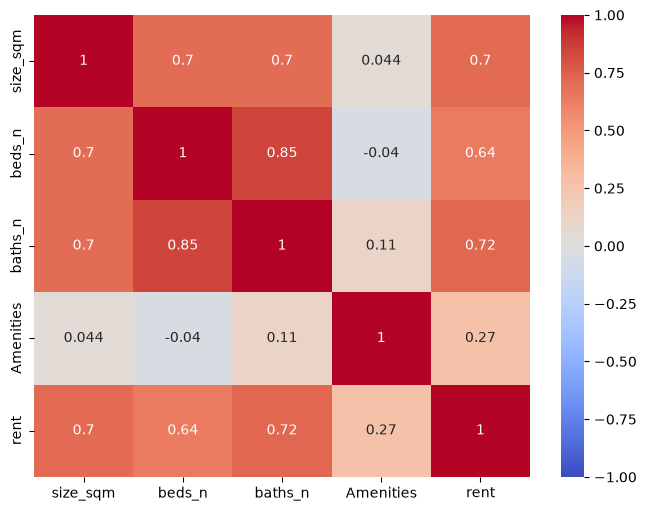

In [130]:
plt.figure(figsize=(8, 6))
sns.heatmap(temp_clean[['size_sqm', 'beds_n', 'baths_n', 'Amenities', 'rent']].corr(),
            annot=True,
            vmin=-1,
            vmax=1,
            cmap='coolwarm')
plt.show()

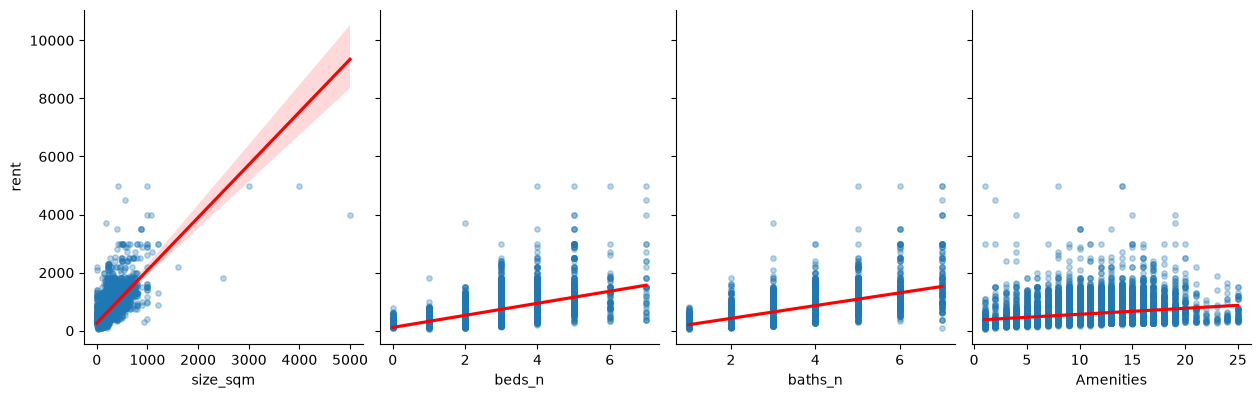

In [131]:
sns.pairplot(temp_clean,
             x_vars=['size_sqm', 'beds_n', 'baths_n', 'Amenities'],
             y_vars='rent',
             height=4,
             aspect=0.8,
             kind='reg',
             plot_kws={'scatter_kws': {'alpha': 0.3, 's': 15},
                       'line_kws': {'color': 'red'}})
plt.show()

In [132]:
# median rent for each governorate, sorted from the most expensive
temp_clean.groupby('Governorate')['rent'].median().sort_values(ascending=False)

Governorate
Northern Governorate    700.0
Southern Governorate    480.0
Capital Governorate     425.0
Muharraq Governorate    400.0
Central Governorate     272.5
Name: rent, dtype: float64

In [133]:
# median rent for each property type
temp_clean.groupby('Property_type')['rent'].median().sort_values(ascending=False)

Property_type
Whole Building                  1500.0
Penthouse                       1000.0
Villa                            950.0
Compound                         850.0
Bungalow                         800.0
Duplex                           704.0
Hotel Apartment                  700.0
Townhouse                        650.0
Apartment                        400.0
Short Term & Hotel Apartment     320.0
Bulk Rent Unit                   100.0
Name: rent, dtype: float64

In [134]:
temp_clean.groupby('Include_w_e')['rent'].median()

Include_w_e
Exclusive    525.0
Inclusive    425.0
Name: rent, dtype: float64

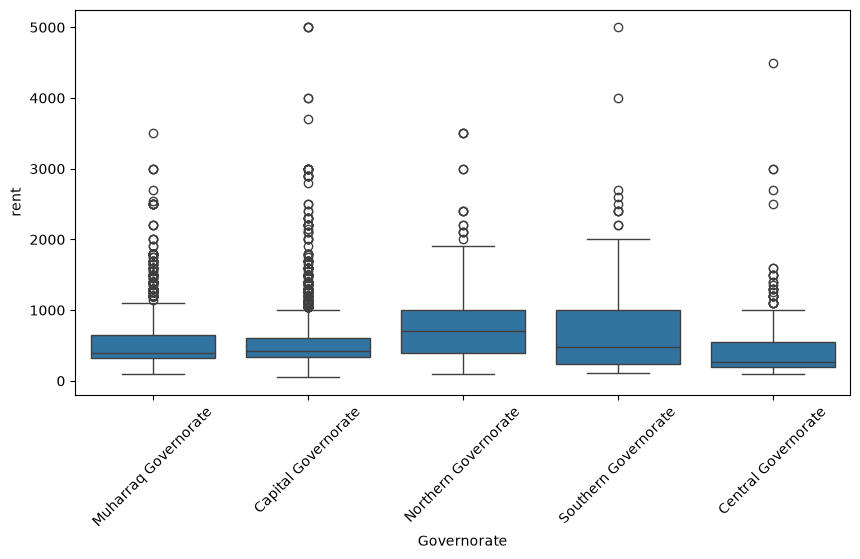

In [135]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=temp_clean, x='Governorate', y='rent')
plt.xticks(rotation=45)
plt.show()

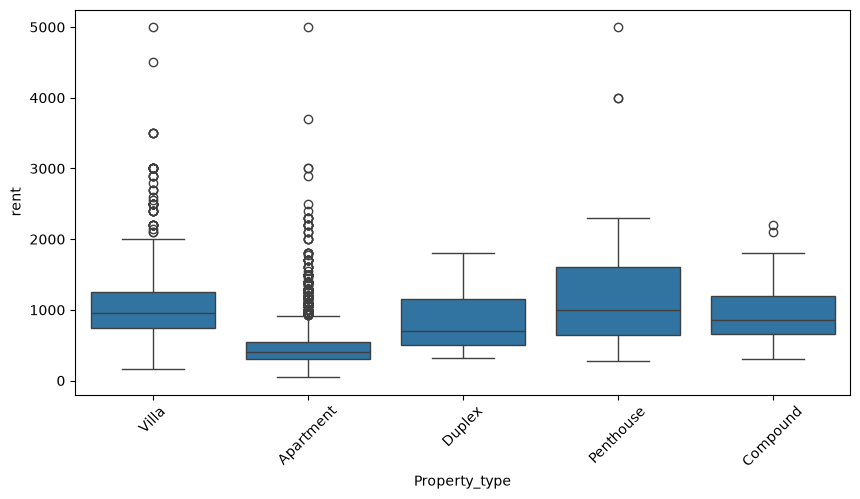

In [136]:
# boxplot of rent by property type, keeping only the main types so the plot stays readable
main_types = ['Apartment', 'Villa', 'Compound', 'Duplex', 'Penthouse']

plt.figure(figsize=(10, 5))
sns.boxplot(data=temp_clean[temp_clean['Property_type'].isin(main_types)], x='Property_type', y='rent')
plt.xticks(rotation=45)
plt.show()

In [137]:
df[df['rent'].isnull()]

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
5194,125,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
6787,25,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
7864,9012,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,NaN,NaN,NaN,2,2,"1,184 sqft / 110 sqm",NaN,NaN,NaN,8.0,NaN


In [138]:
# is Amenities missing randomly, or does missing mean something????
print(f"median rent when Amenities is missing: {df[df['Amenities'].isnull()]['rent'].median()}")
print(f"median rent when Amenities is present: {df[df['Amenities'].notnull()]['rent'].median()}")

median rent when Amenities is missing: 380.0
median rent when Amenities is present: 450.0


In [139]:
temp['size_sqft'] = temp['Size'].str.split('/').str[0].str.replace('sqft', '').str.replace(',', '').astype(float)

temp[['size_sqft', 'size_sqm']].corr()

# Size gives us the SAME information twice (sqft and sqm)

,size_sqft,size_sqm
size_sqft,1.0,1.0
size_sqm,1.0,1.0


In [140]:
df_clean = df.copy()
test_clean = test.copy()

print('rows at the start:', df_clean.shape[0])

rows at the start: 10578


In [141]:
# 1_drop the rows where the target is missing, a row with no rent teaches the model nothing
df_clean = df_clean.dropna(subset=['rent'])
print('after dropping null rent:', df_clean.shape[0])

after dropping null rent: 10575


In [142]:
# 2_drop duplicated listings, the same ad was saved twice under two different Property_id, so we judge duplicates by the URL, because one link = one property
print('duplicated listings:', df_clean.duplicated(subset=['URL']).sum())

df_clean = df_clean.drop_duplicates(subset=['URL'])
print('after dropping duplicates:', df_clean.shape[0])

duplicated listings: 240
after dropping duplicates: 10335


In [143]:
# 3_drop the impossible rents (huge rents / sale prices in the wrong column)
print('rows with rent > 5000:', (df_clean['rent'] > 5000).sum())

df_clean = df_clean[df_clean['rent'] <= 5000]
print('after dropping impossible rents:', df_clean.shape[0])

rows with rent > 5000: 21
after dropping impossible rents: 10314


In [144]:
df_clean = df_clean.reset_index(drop=True)

In [145]:
# A function to do all the column cleaning, to run it on both train and test,


def clean_columns(df):
    '''
    Converts the text columns into numbers,
    and drops the columns we no longer need.
    Works for both the train file and the test file.
    '''
    df = df.copy()

    # we keep sqm only, because sqft and sqm correlate 0.9999 (multicollinearity)
    df['size_sqm'] = (df['Size'].str.split('/').str[1].str.replace('sqm', '').str.replace(',', '').astype(float))

    # a size of exactly 1 sqm is not a real property, we turn it into null and let the pipeline fill it later
    df.loc[df['size_sqm'] == 1, 'size_sqm'] = np.nan

    # Beds : '3+ Maid' -> 3 , 'studio' -> 0
    df['beds_n'] = df['Beds'].str.replace('studio', '0').str[0].astype(float)

    # the "+ Maid" part is real information, so we save it as its own column before losing it
    df['has_maid_room'] = df['Beds'].str.contains('Maid').astype(int)

    # a studio is not the same as a 0-bedroom property, so we flag it too
    df['is_studio'] = df['Beds'].str.contains('studio').astype(int)

    # Baths : "7+" -> 7 , "none" -> null
    df['baths_n'] = pd.to_numeric(df['Baths'].str[0], errors='coerce')

    # Availability_date : "9 Apr 2025" -> a real date 
    df['avail_date'] = pd.to_datetime(df['Availability_date'],format='%d %b %Y',errors='coerce')

    # drop the columns we do not need anymore
    # Offer: always "Rent", it never changes, so it teaches nothing
    # Size, Beds, Baths, Availability_date : we replaced them with the numeric versions
    df = df.drop(columns=['Offer', 'Size', 'Beds', 'Baths', 'Availability_date'])

    return df

In [146]:
df_clean = clean_columns(df_clean)
test_clean = clean_columns(test_clean)

print('train df shape:', df_clean.shape)
print('test df shape:', test_clean.shape)

train df shape: (10314, 17)
test df shape: (3527, 16)


In [147]:
df_clean.dtypes

Property_id               int64
URL                         str
Property_type               str
Include_w_e                 str
Title                       str
Area                        str
Governorate                 str
Agent_name                  str
Agency                      str
Amenities               float64
rent                    float64
size_sqm                float64
beds_n                  float64
has_maid_room             int64
is_studio                 int64
baths_n                 float64
avail_date       datetime64[us]
dtype: object

In [148]:
df_clean[['size_sqm', 'beds_n', 'baths_n', 'has_maid_room', 'is_studio', 'Amenities', 'rent']].describe()

,size_sqm,beds_n,baths_n,has_maid_room,is_studio,Amenities,rent
count,10203.000000,10314.000000,10313.000000,10314.000000,10314.000000,10014.000000,10314.000000
mean,170.589238,2.198274,2.658683,0.209909,0.057495,10.304773,570.592399
std,150.935291,1.200679,1.285646,0.407263,0.232797,5.091589,388.285575
min,2.000000,0.000000,1.000000,0.000000,0.000000,1.000000,50.000000
25%,90.000000,1.000000,2.000000,0.000000,0.000000,6.000000,330.000000
50%,125.000000,2.000000,2.000000,0.000000,0.000000,11.000000,450.000000
75%,180.000000,3.000000,3.000000,0.000000,0.000000,14.000000,700.000000
max,5000.000000,7.000000,7.000000,1.000000,1.000000,25.000000,5000.000000


In [149]:
print(df_clean.isnull().sum())
print(test_clean.isnull().sum())

Property_id        0
URL                0
Property_type      0
Include_w_e        0
Title              0
Area               0
Governorate        0
Agent_name         0
Agency             0
Amenities        300
rent               0
size_sqm         111
beds_n             0
has_maid_room      0
is_studio          0
baths_n            1
avail_date       511
dtype: int64
Property_id        0
URL                0
Property_type      0
Include_w_e        0
Title              0
Area               0
Governorate        0
Agent_name         0
Agency             0
Amenities         86
size_sqm          34
beds_n             0
has_maid_room      0
is_studio          0
baths_n            2
avail_date       168
dtype: int64


In [150]:
print('rent skew before cleaning:', df['rent'].skew())
print('rent skew after cleaning :', df_clean['rent'].skew())

rent skew before cleaning: 53.889106111650975
rent skew after cleaning : 2.800236468092748


In [151]:
df_clean[['size_sqm', 'beds_n', 'baths_n', 'has_maid_room', 'is_studio', 'Amenities', 'rent']].corr()[['rent']]

,rent
size_sqm,0.713722
beds_n,0.641859
baths_n,0.726056
has_maid_room,0.562693
is_studio,-0.189444
Amenities,0.267738
rent,1.000000


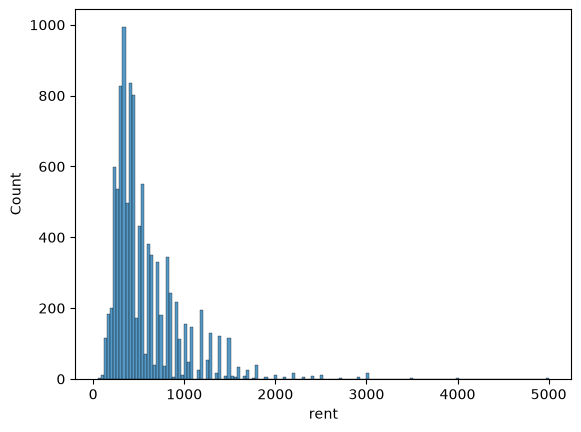

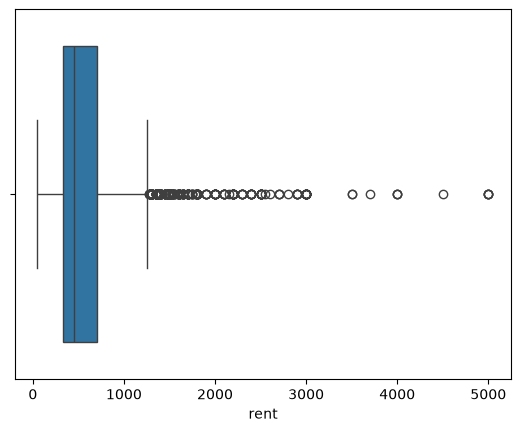

In [152]:
sns.histplot(df_clean['rent'])
plt.show()

sns.boxplot(x=df_clean['rent'])
plt.show()

In [153]:
df_feat = df_clean.copy()
test_feat = test_clean.copy()

In [154]:
# total number of rooms = bedrooms + bathrooms
df_feat['total_rooms'] = df_feat['beds_n'] + df_feat['baths_n']

# how much space per room
df_feat['sqm_per_room'] = df_feat['size_sqm'] / df_feat['total_rooms']

df_feat[['beds_n', 'baths_n', 'total_rooms', 'size_sqm', 'sqm_per_room']].head()

,beds_n,baths_n,total_rooms,size_sqm,sqm_per_room
0,3.0,4.0,7.0,220.0,31.428571
1,5.0,6.0,11.0,300.0,27.272727
2,0.0,1.0,1.0,45.0,45.000000
3,3.0,3.0,6.0,140.0,23.333333
4,5.0,5.0,10.0,450.0,45.000000


In [155]:
# check if the new columns are actually useful
df_feat[['total_rooms', 'sqm_per_room', 'rent']].corr()[['rent']]

,rent
total_rooms,0.712739
sqm_per_room,0.324652
rent,1.000000


In [156]:
df_feat['Title'].head(10)

0               BTRAND NEW LUXURY VILLA FOR RENT AMWAJ
1              First Resident | Quiet Area | Luxurious
2         Studio Apartment for rent located in Juffair
3       Apartment for Rent in Jidhafs – Prime Location
4          Navy Approved| 5 BR | Private Pool |Gardens
5           AMWAJ ISLAND | LUXURIOUS | PRIME LOCATIONS
6    Fully Furnished Beautiful Villa with Private Pool
7    Spacious 4BR Villa with Private Pool in Busaiteen
8    Luxury apartment 2BHK furnished including for ...
9                   Sea View | Luxury Living | Terrace
Name: Title, dtype: str

In [157]:
# a test on one keyword before we do them all
title_lower = df_feat['Title'].str.lower()

df_feat['has_pool'] = title_lower.str.contains('pool').astype(int)

print(df_feat['has_pool'].value_counts())
print('median rent when pool is mentioned    :', df_feat[df_feat['has_pool'] == 1]['rent'].median())
print('median rent when pool is NOT mentioned:', df_feat[df_feat['has_pool'] == 0]['rent'].median())

has_pool
0    8950
1    1364
Name: count, dtype: int64
median rent when pool is mentioned    : 700.0
median rent when pool is NOT mentioned: 425.0


In [158]:
# now for a list of keywords using a for loop
keywords = ['furnish', 'sea view', 'luxur', 'pool', 'gym', 'private','garden', 'compound', 'maid', 'beach', 'balcony', 'view', 'new', 'modern']

title_lower = df_feat['Title'].str.lower()

for word in keywords:
    new_col = 'has_' + word.replace(' ', '_')
    df_feat[new_col] = title_lower.str.contains(word).astype(int)

keyword_cols = ['has_' + word.replace(' ', '_') for word in keywords]

df_feat[keyword_cols].head()

,has_furnish,has_sea_view,has_luxur,has_pool,has_gym,has_private,has_garden,has_compound,has_maid,has_beach,has_balcony,has_view,has_new,has_modern
0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,1,1,0,0,0,0,0,0,0


In [159]:
# how many titles contain each keyword?
df_feat[keyword_cols].sum().sort_values(ascending=False)

has_view        2115
has_furnish     1938
has_balcony     1859
has_luxur       1620
has_pool        1364
has_sea_view    1358
has_modern      1291
has_new         1119
has_private      683
has_garden       649
has_gym          618
has_maid         579
has_beach        431
has_compound     350
dtype: int64

In [160]:
# which keywords actually relate to price?
df_feat[keyword_cols + ['rent']].corr()[['rent']].sort_values('rent', ascending=False)

,rent
rent,1.000000
has_private,0.352588
has_garden,0.276802
has_pool,0.248603
has_compound,0.147588
has_maid,0.121955
has_beach,0.105176
has_luxur,0.089803
has_view,0.071430
has_sea_view,0.065842


In [161]:
df_feat['avail_month'] = df_feat['avail_date'].dt.month

df_feat[['avail_month', 'rent']].corr()[['rent']]

,rent
avail_month,0.036932
rent,1.000000


In [162]:
area_counts = df_feat['Area'].value_counts()
area_counts

Area
Al Juffair                                              1879
Seef                                                     989
Saar                                                     678
Janabiya                                                 518
Hidd                                                     486
                                                        ... 
Al Thurya villa Diyar Al Muharraq, Diyar Al Muharraq       1
Dareena, Dilmunia Island                                   1
Maameer                                                    1
Wahat Al Muharraq                                          1
Adhari, Manama                                             1
Name: count, Length: 126, dtype: int64

In [163]:
# find the areas that appear less than 30 times
rare_areas = area_counts[area_counts < 30].index.to_list()

print('number of rare areas:', len(rare_areas))
print(rare_areas[:10])

number of rare areas: 79
['Maqabah', 'Jannusan', 'Hoora', 'Water Garden City, Manama', 'Manama', 'Riffa Al Sharqi, Riffa', 'Alhajiyat, Riffa', "A'Ali", 'Riffa', 'Gudaibiya, Manama']


In [164]:
# replace all those rare areas with the single label 'Other'
df_feat['Area_grouped'] = df_feat['Area'].replace(rare_areas, 'Other')

print('areas before grouping:', df_feat['Area'].nunique())
print('areas after grouping :', df_feat['Area_grouped'].nunique())
print(df_feat['Area_grouped'].value_counts().head(10))

areas before grouping: 126
areas after grouping : 48
Area_grouped
Al Juffair                     1879
Seef                            989
Other                           818
Saar                            678
Janabiya                        518
Hidd                            486
Amwaj Avenue, Amwaj Islands     422
Busaiteen                       361
Mahooz, Manama                  349
Adliya, Manama                  303
Name: count, dtype: int64


In [165]:
# do the same for the agencies, with a bigger threshold since there are more of them
agency_counts = df_feat['Agency'].value_counts()
rare_agencies = agency_counts[agency_counts < 50].index.to_list()

df_feat['Agency_grouped'] = df_feat['Agency'].replace(rare_agencies, 'Other')

print('agencies before grouping:', df_feat['Agency'].nunique())
print('agencies after grouping :', df_feat['Agency_grouped'].nunique())

agencies before grouping: 204
agencies after grouping : 65


In [166]:
# A function that creates all our new features, on BOTH train and test so they stay identical


def add_features(df):
    '''
    Creates the ratio features, the Title keyword flags, and the month feature.
    '''
    df = df.copy()

    # combining the numbers
    df['total_rooms'] = df['beds_n'] + df['baths_n']
    df['sqm_per_room'] = df['size_sqm'] / df['total_rooms']

    # if total_rooms is 0 the division gives infinity, we turn those into nulls so the imputer can fill them normally
    df['sqm_per_room'] = df['sqm_per_room'].replace([np.inf, -np.inf], np.nan)

    # keyword flags from the Title
    title_lower = df['Title'].str.lower()
    for word in keywords:
        new_col = 'has_' + word.replace(' ', '_')
        df[new_col] = title_lower.str.contains(word).astype(int)

    # date
    df['avail_month'] = df['avail_date'].dt.month

    return df

In [167]:
df_feat = add_features(df_clean)
test_feat = add_features(test_clean)

print('train shape:', df_feat.shape)
print('test  shape:', test_feat.shape)

train shape: (10314, 34)
test  shape: (3527, 33)


In [168]:
# now the grouped categories

area_counts = df_feat['Area'].value_counts()
rare_areas = area_counts[area_counts < 30].index.to_list()

agency_counts = df_feat['Agency'].value_counts()
rare_agencies = agency_counts[agency_counts < 50].index.to_list()

# apply the SAME lists to both files
df_feat['Area_grouped'] = df_feat['Area'].replace(rare_areas, 'Other')
test_feat['Area_grouped'] = test_feat['Area'].replace(rare_areas, 'Other')

df_feat['Agency_grouped'] = df_feat['Agency'].replace(rare_agencies, 'Other')
test_feat['Agency_grouped'] = test_feat['Agency'].replace(rare_agencies, 'Other')

print('train areas:', df_feat['Area_grouped'].nunique())
print('test  areas:', test_feat['Area_grouped'].nunique())

train areas: 48
test  areas: 49


In [169]:
# check for any category that exists in test but not in train
print('areas in test but not in train   :', set(test_feat['Area_grouped'].unique()) - set(df_feat['Area_grouped'].unique()))
print('agencies in test but not in train:', set(test_feat['Agency_grouped'].unique()) - set(df_feat['Agency_grouped'].unique()))

areas in test but not in train   : {'Dumistan'}
agencies in test but not in train: {'Bin Ghareeb Trading Company W.L.L'}


In [170]:
# check the new columns have no strange values
df_feat[['total_rooms', 'sqm_per_room', 'avail_month']].describe()

,total_rooms,sqm_per_room,avail_month
count,10313.000000,10202.000000,9803.000000
mean,4.857171,34.292193,7.516271
std,2.390841,14.707475,2.125288
min,1.000000,0.200000,1.000000
25%,3.000000,26.000000,7.000000
50%,4.000000,30.000000,8.000000
75%,6.000000,38.888889,9.000000
max,14.000000,470.000000,12.000000


In [171]:
# full correlation view of everything numeric we now have
df_feat.corr(numeric_only=True)[['rent']].sort_values('rent', ascending=False)

,rent
rent,1.000000
baths_n,0.726056
size_sqm,0.713722
total_rooms,0.712739
beds_n,0.641859
has_maid_room,0.562693
has_private,0.352588
sqm_per_room,0.324652
has_garden,0.276802
Amenities,0.267738


In [172]:
drop_cols = ['Property_id', 'URL', 'Title', 'Area', 'Agency', 'Agent_name', 'avail_date']

In [173]:
X = df_feat.drop(columns=drop_cols + ['rent'])
y = df_feat['rent']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (10314, 28)
y shape: (10314,)


In [174]:
X.dtypes

Property_type         str
Include_w_e           str
Governorate           str
Amenities         float64
size_sqm          float64
beds_n            float64
has_maid_room       int64
is_studio           int64
baths_n           float64
total_rooms       float64
sqm_per_room      float64
has_furnish         int64
has_sea_view        int64
has_luxur           int64
has_pool            int64
has_gym             int64
has_private         int64
has_garden          int64
has_compound        int64
has_maid            int64
has_beach           int64
has_balcony         int64
has_view            int64
has_new             int64
has_modern          int64
avail_month       float64
Area_grouped          str
Agency_grouped        str
dtype: object

In [175]:
# GROUP 1 - numeric columns that are skewed, PowerTransformer, then scaling.
num_cols_skew = ['size_sqm', 'sqm_per_room', 'total_rooms']

# GROUP 2 - numeric columns with a normal shape only scaling
num_cols_normal = ['Amenities', 'beds_n', 'baths_n', 'avail_month']

# GROUP 3 - flag columns that are 0 or 1, these need nothing
flag_cols = ['is_studio', 'has_maid_room','has_furnish', 'has_sea_view', 'has_luxur', 'has_pool', 'has_gym','has_private', 'has_garden', 'has_compound', 'has_maid', 'has_beach','has_balcony', 'has_view', 'has_new', 'has_modern']

# GROUP 4 - text categories, OneHotEncoder
cat_cols = ['Property_type', 'Include_w_e', 'Governorate', 'Area_grouped', 'Agency_grouped']

In [176]:
myutil.evaluate_skewness(X)

Note: Skewness will be null if a column contains any null value


,Feature,Skewness Type,Skewness Value,Skewness level,Recommendation
0,Amenities,Symmetrical,-0.02,,None needed
1,size_sqm,Right-Skewed,7.53,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
3,sqm_per_room,Right-Skewed,6.23,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
4,avail_month,Left-Skewed,-1.19,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
2,total_rooms,Right-Skewed,0.81,Moderately skewed,"Log1p, Box-Cox or Yeo-Johnson"


In [177]:
myutil.evaluate_skewness(X, filter_result=True)

Note: Skewness will be null if a column contains any null value


,Feature,Skewness Type,Skewness Value,Skewness level,Recommendation
0,size_sqm,Right-Skewed,7.53,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
1,sqm_per_room,Right-Skewed,6.23,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
2,avail_month,Left-Skewed,-1.19,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
3,total_rooms,Right-Skewed,0.81,Moderately skewed,"Log1p, Box-Cox or Yeo-Johnson"


In [178]:
# how skewed is the target after cleaning
print('rent skewness:', y.skew())
print('log rent skewness:', np.log(y).skew())

rent skewness: 2.800236468092748
log rent skewness: 0.41994903617250845


In [179]:
# keep both versions of the target so I can compare them fairly later
y_log = np.log(y)

print('y:', y.head().to_list())
print('y_log:', y_log.head().round(3).to_list())

y: [1000.0, 700.0, 260.0, 250.0, 1280.0]
y_log: [6.908, 6.551, 5.561, 5.521, 7.155]


In [180]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (8251, 28)
X_test : (2063, 28)
y_train: (8251,)
y_test : (2063,)


In [181]:
# now I split the log target the same way, using the SAME random_state
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log,test_size=0.2,random_state=42)

In [182]:
from sklearn.metrics import mean_absolute_error

# the simplest model: ignore all the features,
# just predict (the median rent) for every single property
median_prediction = np.full(len(y_test), y_train.median())

print('predicting the median for everyone:')
print('MAE =', mean_absolute_error(y_test, median_prediction))

predicting the median for everyone:
MAE = 238.30198739699466


In [183]:
# predicting the mean instead
mean_prediction = np.full(len(y_test), y_train.mean())

print('predicting the mean for everyone:')
print('MAE =', mean_absolute_error(y_test, mean_prediction))

predicting the mean for everyone:
MAE = 266.54579614991655


In [184]:
# use only the single feature: size_sqm
X_train_simple = X_train[['size_sqm']]
X_test_simple = X_test[['size_sqm']]

size_median = X_train_simple['size_sqm'].median()

X_train_simple = X_train_simple.fillna(size_median)
X_test_simple = X_test_simple.fillna(size_median)

print('median used for filling:', size_median)

median used for filling: 125.0


In [185]:
from sklearn.linear_model import LinearRegression

lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)

print('intercept:', lr_simple.intercept_)
print('coef:', lr_simple.coef_)

intercept: 264.2304640012571
coef: [1.81665994]


In [186]:
result_simple = myutil.evaluate_model(lr_simple, X_train_simple, X_test_simple,y_train, y_test, 'Simple LR (size only)')

--- Simple LR (size only) Performance ---
mae   for train = 176.45002260436442, and for test = 175.02909174244607
rmse  for train = 276.978302772721, and for test = 259.70340292270686
score for train = 0.5073880187490848, and for test = 0.4824889365350201


In [187]:
# now I will use every numeric column (still no categories)
numeric_features = ['size_sqm', 'sqm_per_room', 'total_rooms','Amenities', 'beds_n', 'baths_n', 'avail_month'] + flag_cols

train_medians = X_train[numeric_features].median()

X_train_num = X_train[numeric_features].fillna(train_medians)
X_test_num = X_test[numeric_features].fillna(train_medians)

lr_numeric = LinearRegression()
lr_numeric.fit(X_train_num, y_train)

result_numeric = myutil.evaluate_model(lr_numeric, X_train_num, X_test_num,y_train, y_test, 'LR (all numeric)')

--- LR (all numeric) Performance ---
mae   for train = 141.71709353278732, and for test = 140.52541891608564
rmse  for train = 222.40533798105156, and for test = 213.82573957587664
score for train = 0.6823828940678532, and for test = 0.6491800165089587


In [188]:
# fit exactly the same model, but on the log of the target
lr_log = LinearRegression()
lr_log.fit(X_train_num, y_train_log)

pred_log = lr_log.predict(X_test_num)
pred_bhd = np.exp(pred_log)

In [189]:
# now we compare the two versions fairly, both measured in BHD
print('MAE with raw target :', mean_absolute_error(y_test, lr_numeric.predict(X_test_num)))
print('MAE with log target :', mean_absolute_error(y_test, pred_bhd))

MAE with raw target : 140.52541891608564
MAE with log target : 134.69418857137728


In [190]:
# collect every model's results so I can compare them all
results = []
results.append(result_simple)
results.append(result_numeric)

pd.DataFrame(results)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Simple LR (size only),176.450023,175.029092,276.978303,259.703403,0.507388,0.482489
1,LR (all numeric),141.717094,140.525419,222.405338,213.825740,0.682383,0.649180


In [191]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [192]:
# GROUP 1 - the skewed numeric columns
# fill the gaps with the median, fix the skewness, then scale
skew_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('transformer', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])
# GROUP 2 - the normal numeric columns
# fill the gaps with the median, then scale
normal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# GROUP 3 - the categorical columns
# fill the gaps with the most frequent value, then turn the text into 1 and 0 columns
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

In [193]:
preprocessor = ColumnTransformer([
    ('skewed', skew_pipe, num_cols_skew),
    ('normal', normal_pipe, num_cols_normal),
    ('flags', 'passthrough', flag_cols),
    ('categorical', cat_pipe, cat_cols)
])

In [194]:
main_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

main_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('normal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defaul

In [195]:
# Same idea as myutil.evaluate_model, but it converts the predictions back to BD with np.exp

def evaluate_log_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    print(f"--- {model_name} Performance ---")

    # predict, then undo the log with np.exp to get back to dinars
    y_train_pred = np.exp(model.predict(X_train))
    y_test_pred = np.exp(model.predict(X_test))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f'mae   for train = {train_mae}, and for test = {test_mae}')
    print(f'rmse  for train = {train_rmse}, and for test = {test_rmse}')
    print(f'score for train = {train_r2}, and for test = {test_r2}')

    return {'Model': model_name,
            'Train MAE': train_mae, 'Test MAE': test_mae,
            'Train RMSE': train_rmse, 'Test RMSE': test_rmse,
            'Train R2': train_r2, 'Test R2': test_r2}

In [196]:
main_pipe.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['Property_type','Include_w_e','Governorate',...,'avail_month', 'Area_grouped','Agency_grouped']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('normal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pa

In [197]:
result_pipe = evaluate_log_model(main_pipe, X_train, X_test, y_train, y_test,'Full pipeline LR (log target)')

--- Full pipeline LR (log target) Performance ---
mae   for train = 107.20461844188388, and for test = 105.106658512368
rmse  for train = 188.65922883889016, and for test = 179.64290656204625
score for train = 0.7714561280714415, and for test = 0.7523806926186623


In [198]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(main_pipe, X, y_log, cv=kf)

print('R2 for each fold:', cv_r2)
print('average R2:', cv_r2.mean())

R2 for each fold: [0.81577562 0.84088529 0.83859185 0.8239669  0.80476339]
average R2: 0.8247966123447711


In [199]:
# cross validation using MAE
cv_mae = cross_val_score(main_pipe, X, y_log, cv=kf, scoring='neg_mean_absolute_error')

print('MAE for each fold:', -cv_mae)
print('average MAE:', -cv_mae.mean())

MAE for each fold: [0.17819307 0.17411951 0.17160122 0.17797295 0.18833589]
average MAE: 0.17804452684589686


In [200]:
# add the pipeline results to our comparison list
results.append(result_pipe)

pd.DataFrame(results).sort_values('Test MAE')

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
2,Full pipeline LR (log target),107.204618,105.106659,188.659229,179.642907,0.771456,0.752381
1,LR (all numeric),141.717094,140.525419,222.405338,213.825740,0.682383,0.649180
0,Simple LR (size only),176.450023,175.029092,276.978303,259.703403,0.507388,0.482489


In [201]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# start a fresh results list for now
results = []

# MODEL 1 - plain LinearRegression, our reference point
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipe.fit(X_train, y_train_log)

results.append(evaluate_log_model(lr_pipe, X_train, X_test, y_train, y_test, 'LinearRegression'))

--- LinearRegression Performance ---
mae   for train = 107.20461844188388, and for test = 105.106658512368
rmse  for train = 188.65922883889016, and for test = 179.64290656204625
score for train = 0.7714561280714415, and for test = 0.7523806926186623


In [202]:
# MODEL 2 - Ridge
alphas = np.logspace(-2, 3, 100)

ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=alphas, cv=kf))
])

ridge_pipe.fit(X_train, y_train_log)

print('best alpha:', ridge_pipe.named_steps['model'].alpha_)

best alpha: 0.2915053062825176


In [203]:
results.append(evaluate_log_model(ridge_pipe, X_train, X_test, y_train, y_test, 'RidgeCV'))

--- RidgeCV Performance ---
mae   for train = 107.22181471202187, and for test = 105.12359468850876
rmse  for train = 188.74121886917797, and for test = 179.77398846969848
score for train = 0.7712574376509359, and for test = 0.7520191948680671


In [204]:
# MODEL 3 - Lasso
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=kf, random_state=42, max_iter=10000))
])

lasso_pipe.fit(X_train, y_train_log)

print('best alpha:', lasso_pipe.named_steps['model'].alpha_)

best alpha: 0.0004209819558983827


In [205]:
results.append(evaluate_log_model(lasso_pipe, X_train, X_test, y_train, y_test, 'LassoCV'))

--- LassoCV Performance ---
mae   for train = 110.08345844083229, and for test = 107.35307849781876
rmse  for train = 193.90933761554382, and for test = 185.14256288610437
score for train = 0.758559058094938, and for test = 0.7369871903549152


In [206]:
# MODEL 4 - ElasticNet
elastic_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1],cv=kf, random_state=42, max_iter=10000))
])

elastic_pipe.fit(X_train, y_train_log)

print('best alpha:', elastic_pipe.named_steps['model'].alpha_)
print('best l1_ratio:', elastic_pipe.named_steps['model'].l1_ratio_)

best alpha: 0.0004209819558983827
best l1_ratio: 1.0


In [207]:
results.append(evaluate_log_model(elastic_pipe, X_train, X_test, y_train, y_test, 'ElasticNetCV'))

--- ElasticNetCV Performance ---
mae   for train = 110.08345844083229, and for test = 107.35307849781876
rmse  for train = 193.90933761554382, and for test = 185.14256288610437
score for train = 0.758559058094938, and for test = 0.7369871903549152


In [208]:
results_df = pd.DataFrame(results).sort_values('Test MAE')
results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,LinearRegression,107.204618,105.106659,188.659229,179.642907,0.771456,0.752381
1,RidgeCV,107.221815,105.123595,188.741219,179.773988,0.771257,0.752019
2,LassoCV,110.083458,107.353078,193.909338,185.142563,0.758559,0.736987
3,ElasticNetCV,110.083458,107.353078,193.909338,185.142563,0.758559,0.736987


In [209]:
from sklearn.linear_model import Ridge

# to try different thresholds for grouping the rare areas
for threshold in [5, 10, 20, 30, 50]:

    area_counts = df_feat['Area'].value_counts()
    rare_areas = area_counts[area_counts < threshold].index.to_list()

    X_try = X.copy()
    X_try['Area_grouped'] = df_feat['Area'].replace(rare_areas, 'Other')

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1))
    ])
    cv = cross_val_score(pipe, X_try, y_log, cv=kf, scoring='neg_mean_absolute_error')

    print(f'threshold {threshold} -> {X_try["Area_grouped"].nunique()} categories, CV MAE (log) = {-cv.mean()}')

threshold 5 -> 97 categories, CV MAE (log) = 0.17422306326544995
threshold 10 -> 87 categories, CV MAE (log) = 0.1744225961742419
threshold 20 -> 64 categories, CV MAE (log) = 0.176040066962058
threshold 30 -> 48 categories, CV MAE (log) = 0.17796377134991676
threshold 50 -> 38 categories, CV MAE (log) = 0.18086635708607515


In [210]:
# and to bring back Agent_name, grouped properly instead of dropped
for threshold in [10, 20, 30, 50]:

    agent_counts = df_feat['Agent_name'].value_counts()
    rare_agents = agent_counts[agent_counts < threshold].index.to_list()

    X_try = X.copy()
    X_try['Agent_grouped'] = df_feat['Agent_name'].replace(rare_agents, 'Other')

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1))
    ])
    cv = cross_val_score(pipe, X_try, y_log, cv=kf, scoring='neg_mean_absolute_error')

    print(f'threshold {threshold} -> {X_try["Agent_grouped"].nunique()} categories, CV MAE (log) = {-cv.mean()}')

threshold 10 -> 229 categories, CV MAE (log) = 0.17796377134991676
threshold 20 -> 154 categories, CV MAE (log) = 0.17796377134991676
threshold 30 -> 109 categories, CV MAE (log) = 0.17796377134991676
threshold 50 -> 60 categories, CV MAE (log) = 0.17796377134991676


In [211]:
# rebuild the features with the best thresholds we just found
area_counts = df_feat['Area'].value_counts()
rare_areas = area_counts[area_counts < 5].index.to_list()

agency_counts = df_feat['Agency'].value_counts()
rare_agencies = agency_counts[agency_counts < 10].index.to_list()

agent_counts = df_feat['Agent_name'].value_counts()
rare_agents = agent_counts[agent_counts < 20].index.to_list()


for data in [df_feat, test_feat]:
    data['Area_grouped'] = data['Area'].replace(rare_areas, 'Other')
    data['Agency_grouped'] = data['Agency'].replace(rare_agencies, 'Other')
    data['Agent_grouped'] = data['Agent_name'].replace(rare_agents, 'Other')

print('Area categories:', df_feat['Area_grouped'].nunique())
print('Agency categories:', df_feat['Agency_grouped'].nunique())
print('Agent categories:', df_feat['Agent_grouped'].nunique())

Area categories: 97
Agency categories: 135
Agent categories: 154


In [212]:
# lets add Agent_grouped to the categorical list
cat_cols = ['Property_type', 'Include_w_e', 'Governorate','Area_grouped', 'Agency_grouped', 'Agent_grouped']

X = df_feat.drop(columns=drop_cols + ['rent'])
y = df_feat['rent']
y_log = np.log(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

print('X shape:', X.shape)

X shape: (10314, 29)


In [213]:
# rebuild the preprocessor so it picks up the new cat_cols list
preprocessor = ColumnTransformer([
    ('skewed', skew_pipe, num_cols_skew),
    ('normal', normal_pipe, num_cols_normal),
    ('flags', 'passthrough', flag_cols),
    ('categorical', cat_pipe, cat_cols)
])

In [214]:
from sklearn.model_selection import GridSearchCV

main_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [215]:
# every setting we want to test, with the values to try
param_grid = {
    'preprocessor__skewed__imputer__strategy': ['median', 'mean'],
    'preprocessor__normal__imputer__strategy': ['median', 'mean'],
    'preprocessor__skewed__transformer': [PowerTransformer(method='yeo-johnson'), 'passthrough'],
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

In [216]:
grid_search = GridSearchCV(main_pipe,param_grid,cv=kf,scoring='neg_mean_absolute_error',n_jobs=-1,verbose=1)

grid_search.fit(X_train, y_train_log)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...], 'preprocessor__normal__imputer__strategy': ['median', 'mean'], 'preprocessor__skewed__imputer__strategy': ['median', 'mean'], 'preprocessor__skewed__transformer': [PowerTransformer(), 'passthrough']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set

In [217]:
result_grid = evaluate_log_model(grid_search.best_estimator_, X_train, X_test,y_train, y_test, 'GridSearchCV Ridge')

--- GridSearchCV Ridge Performance ---
mae   for train = 100.02539721578195, and for test = 100.45590395357826
rmse  for train = 176.75354134599067, and for test = 173.45311874980735
score for train = 0.7993913207050849, and for test = 0.7691506882136407


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'preprocessor__skewed__imputer__strategy': ['median', 'mean'],
    'preprocessor__normal__imputer__strategy': ['median', 'mean'],
    'preprocessor__skewed__transformer': [PowerTransformer(method='yeo-johnson'), 'passthrough'],
    'model__alpha': np.logspace(-3, 2, 100)
}

random_search = RandomizedSearchCV(main_pipe,param_dist,n_iter=30,cv=kf,scoring='neg_mean_absolute_error',random_state=42,n_jobs=-1)
random_search.fit(X_train, y_train_log)

In [ ]:
result_random = evaluate_log_model(random_search.best_estimator_, X_train, X_test,y_train, y_test, 'RandomizedSearchCV Ridge')

In [ ]:
results.append(result_grid)
results.append(result_random)

pd.DataFrame(results).sort_values('Test MAE')

In [ ]:
final_model = grid_search.best_estimator_

final_model

In [ ]:
# I give the model every row we have so it learns as much as possible
final_model.fit(X, y_log)

In [ ]:
X_kaggle = test_feat[X.columns]


In [ ]:
pred_log = final_model.predict(X_kaggle)
pred_rent = np.exp(pred_log)

In [ ]:
sample.head()

In [ ]:
submission = pd.DataFrame({
    'Property_id': test_feat['Property_id'],
    'rent': pred_rent
})

submission.head()

In [ ]:
submission.to_csv('final_submission.csv', index=False)

In [ ]:
import joblib
joblib.dump(final_model, 'final_model.pkl')

In [ ]:
# check it loads back and gives the same predictions
loaded_model = joblib.load('final_model.pkl')

print('predictions match:', np.allclose(np.exp(loaded_model.predict(X_kaggle)), pred_rent))